In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn import metrics

In [2]:
Data = pd.read_csv("cardata.csv")
df = pd.DataFrame(Data)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    This dataset contains information about cars and their prices based on various factors. The goal is to evaluate the price of each car according to features such as Year, Present Price, Kilometers Driven, Fuel Type (Petrol, Diesel, Other), Seller Type (Dealer, Individual), Transmission (Manual, Automatic), and Owner.
  </h2>
</div>

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [4]:
df.describe(include="all")

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


In [5]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [7]:
df1 = df.drop_duplicates()
df1

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


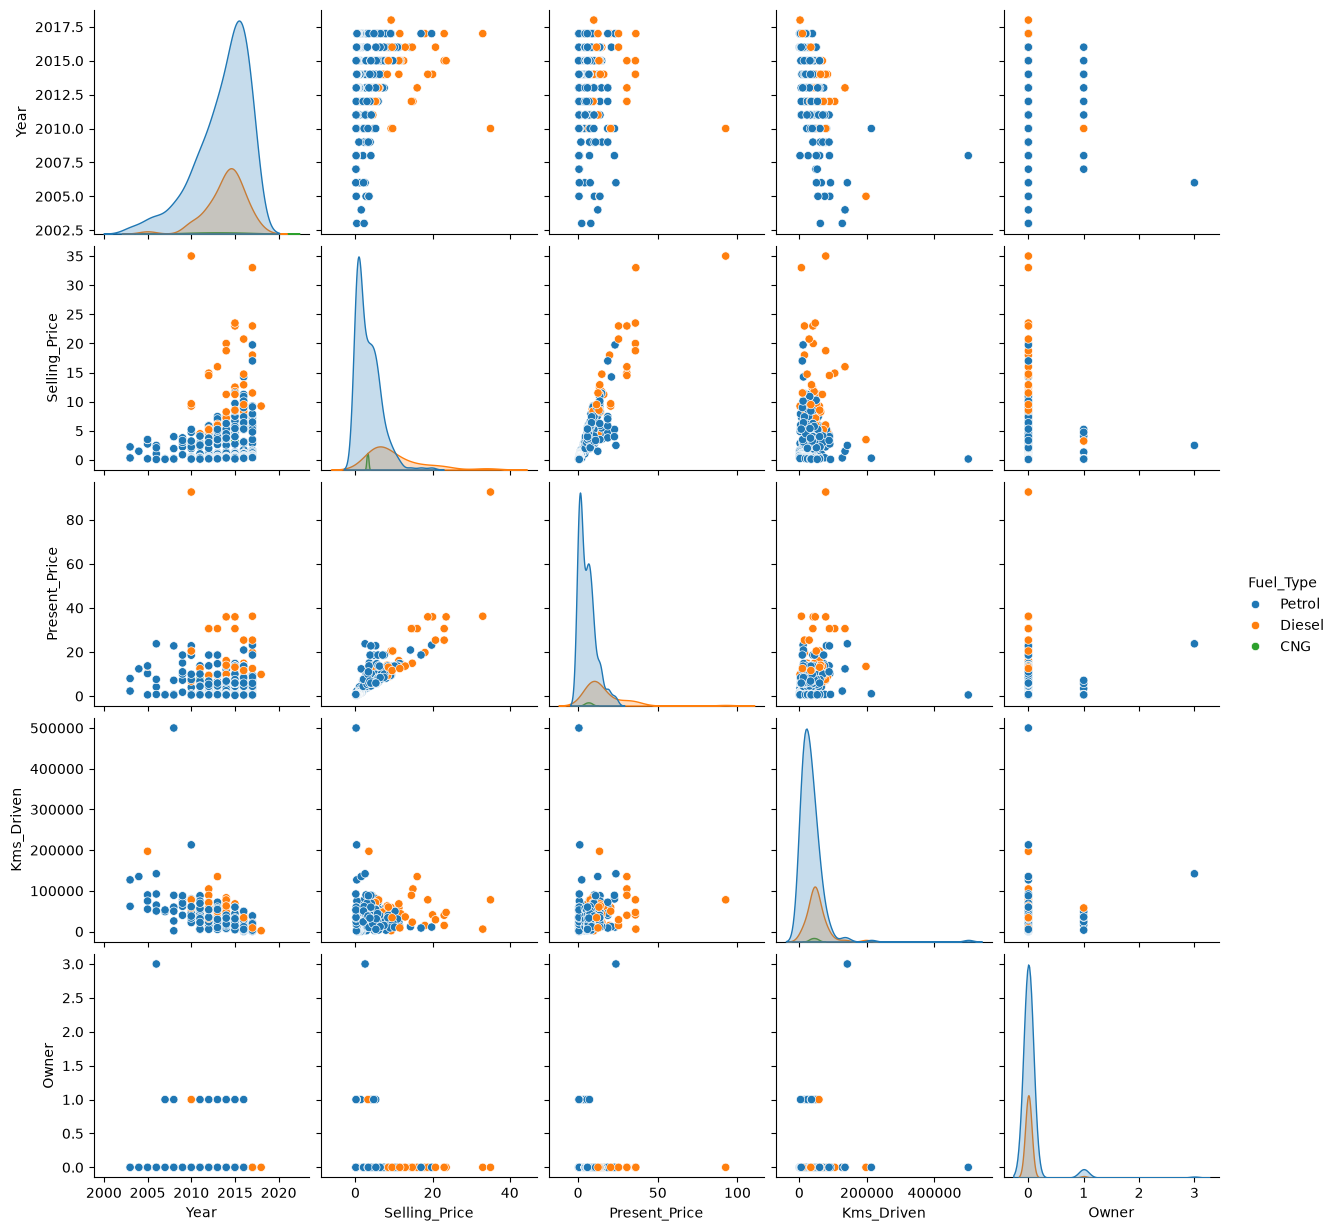

In [8]:
sns.pairplot(df1,hue="Fuel_Type")

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    There appears to be some noise in the data, so further investigation is needed.
  </h2>
</div>

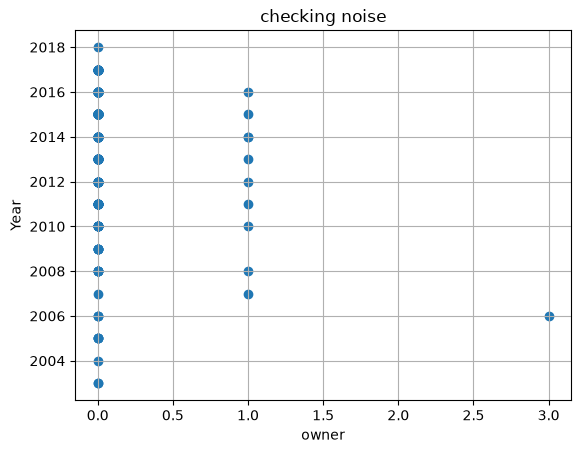

In [9]:
plt.scatter(df1["Owner"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("owner")
plt.ylabel("Year")
plt.show()

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    The Owner = 3 category appears to have only one sample. By examining the other features of this sample, it can be determined whether it is noise or not. However, even if it is not noise, having only a single value may prevent the model from properly learning the behavior of this sample.
  </h2>
</div>

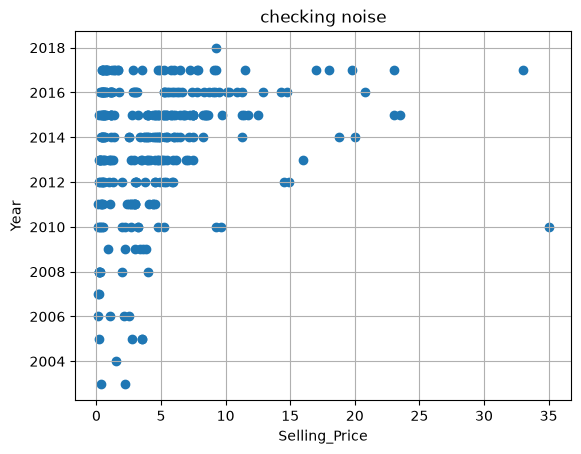

In [10]:
plt.scatter(df1["Selling_Price"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Selling_Price")
plt.ylabel("Year")
plt.show()

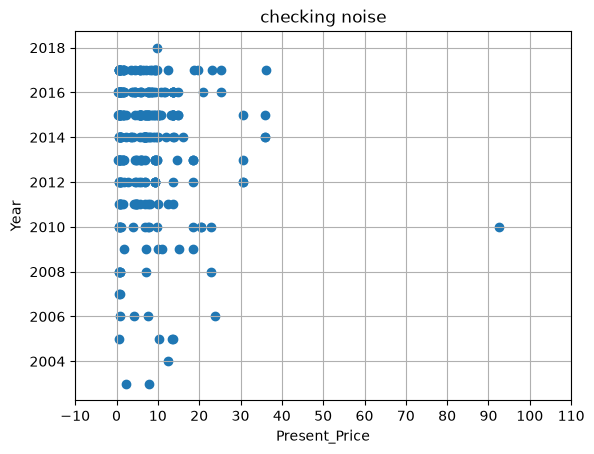

In [11]:
plt.scatter(df1["Present_Price"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Present_Price")
plt.ylabel("Year")

plt.xlim(-10,110)
plt.xticks(range(-10,111,10))
plt.show()

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    One of the values in the Present_Price feature is an outlier and is suspected to be noise.
  </h2>
</div>

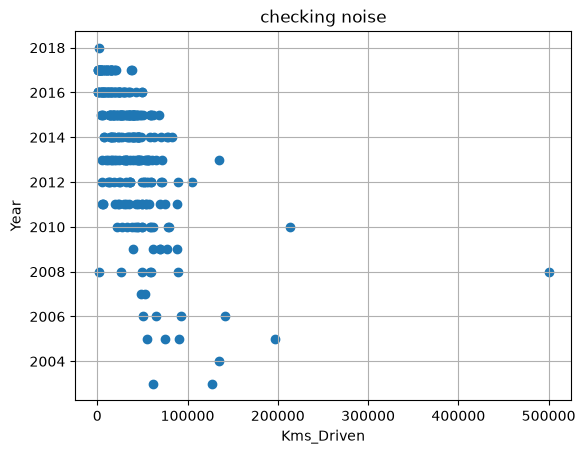

In [12]:
plt.scatter(df1["Kms_Driven"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Kms_Driven")
plt.ylabel("Year")
plt.show()

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    The "Number of Kilometers Driven" column contains a value of 500,000 km, which is significantly higher than the other samples. This appears to be an outlier and is suspected to be noise.
  </h2>
</div>

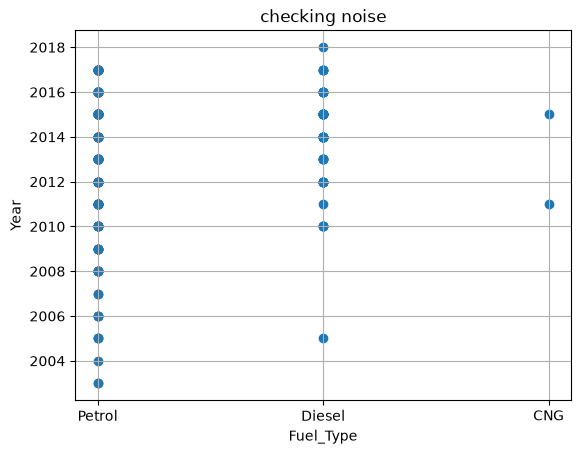

In [13]:
plt.scatter(df1["Fuel_Type"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Fuel_Type")
plt.ylabel("Year")
plt.show()

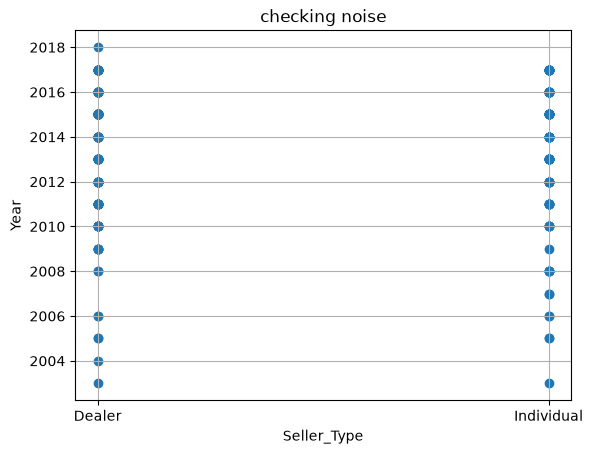

In [14]:
plt.scatter(df1["Seller_Type"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Seller_Type")
plt.ylabel("Year")
plt.show()

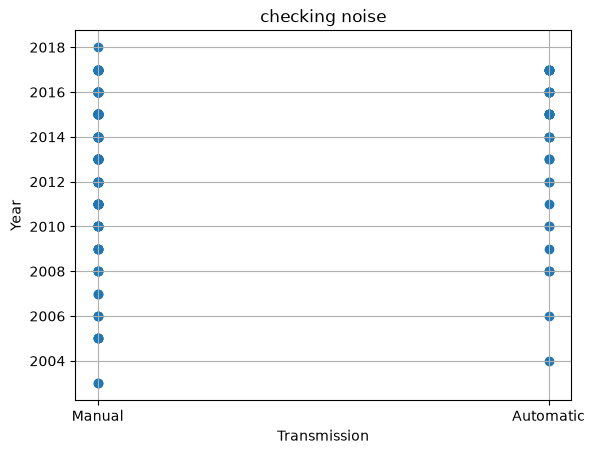

In [15]:
plt.scatter(df1["Transmission"], df1["Year"])
plt.grid()
plt.title("checking noise")
plt.xlabel("Transmission")
plt.ylabel("Year")
plt.show()

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    Finding Values Suspected to Be Noise
  </h2>
</div>

In [16]:
df1[(df1["Owner"]>2)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
85,camry,2006,2.5,23.73,142000,Petrol,Individual,Automatic,3


<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    It does not appear to be noise, but there is only one sample for Owner = 3 in the dataset.
  </h2>
</div>

In [17]:
df1[ (df1["Present_Price"]>90)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
86,land cruiser,2010,35.0,92.6,78000,Diesel,Dealer,Manual,0


In [18]:
df1[(df1["Selling_Price"]>25)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
64,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0
86,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0


<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    Index 86 appears to be noise.
  </h2>
</div>

In [19]:
df1[(df1["Kms_Driven"]>400000)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    Index 196 appears to be noise.
  </h2>
</div>

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 20px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 20px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    Since there is no contact with the data owner to determine whether the samples are noise or genuine, we remove the clearly identifiable outlier and suspected noise samples from the dataframe to prevent issues during modeling.
  </h2>
</div>

<div style="
  margin: 25px 0 15px 0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 600;
    color: #1e40af;
    margin: 0;
    display: flex;
    align-items: center;
    gap: 8px;
  ">
    <span style="
      display: inline-block;
      width: 6px;
      height: 24px;
      background: #3b82f6;
      border-radius: 3px;
    "></span>
    Modeling is first performed without cleaning the outliers and noise, then repeated after their removal, and the results are compared.
  </h2>
</div>

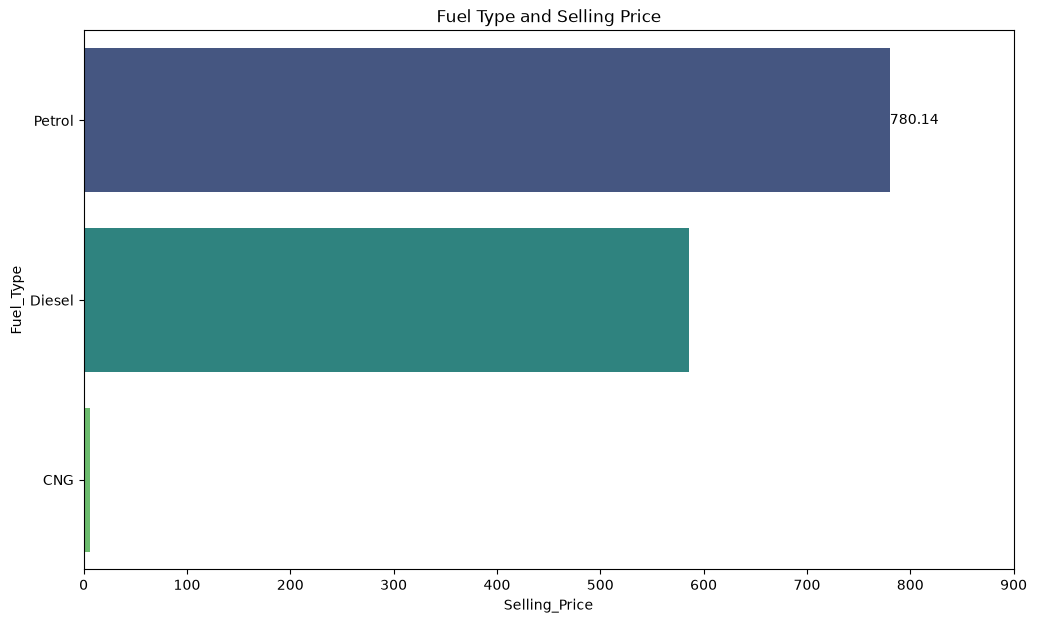

In [20]:
plt.figure(figsize=(12,7))

g = sns.barplot(
    data=df1,
    x="Selling_Price",
    y="Fuel_Type",
    estimator="sum",
    errorbar=None,
    hue="Fuel_Type",
    palette="viridis",
    legend=False
)

g.bar_label(g.containers[0], fontsize=10)

plt.title("Fuel Type and Selling Price")

plt.xticks(np.arange(0, 1000, 100))

plt.show()

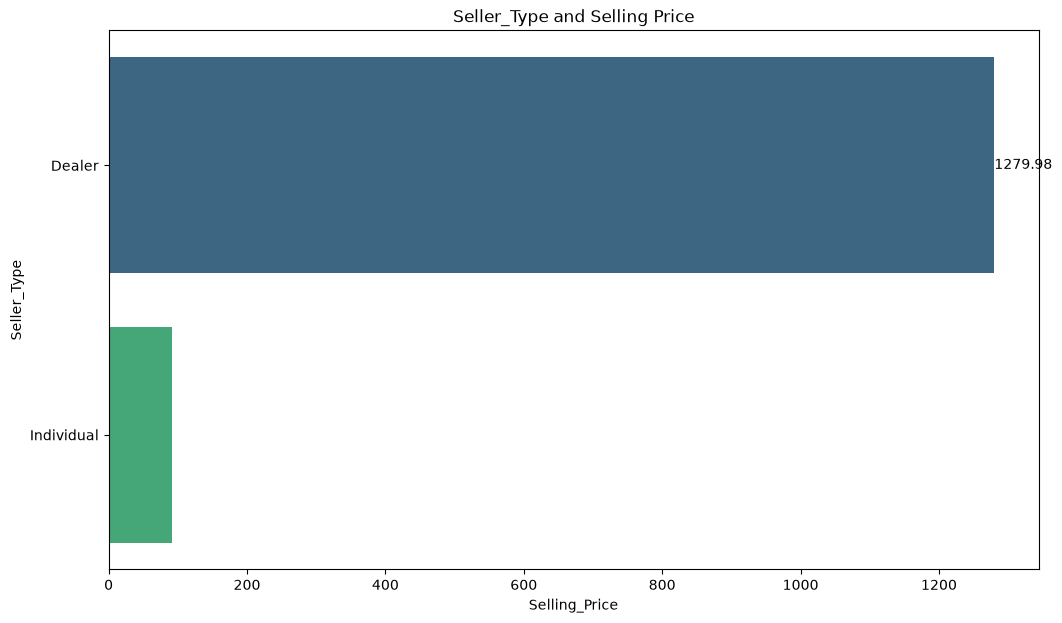

In [21]:
plt.figure(figsize=(12,7))

g = sns.barplot(
    data=df1,
    x="Selling_Price",
    y="Seller_Type",
    estimator="sum",
    errorbar=None,
    hue="Seller_Type",
    palette="viridis",
    legend=False
)

g.bar_label(g.containers[0], fontsize=10)

plt.title("Seller_Type and Selling Price")

# plt.xticks(np.arange(0, 1000, 100))

plt.show()

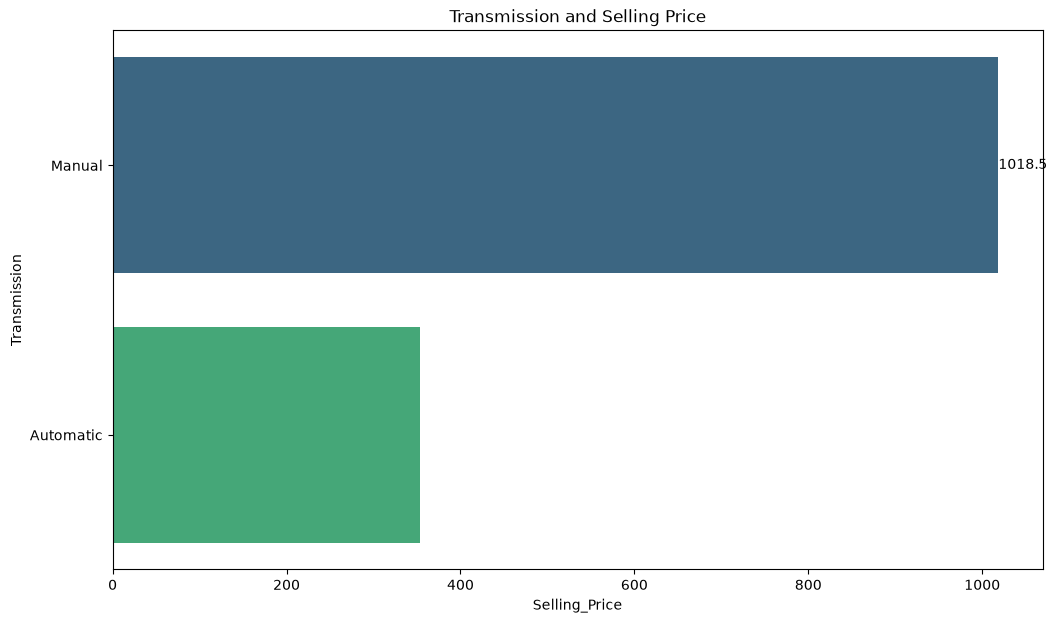

In [22]:
plt.figure(figsize=(12,7))

g = sns.barplot(
    data=df1,
    x="Selling_Price",
    y="Transmission",
    estimator="sum",
    errorbar=None,
    hue="Transmission",
    palette="viridis",
    legend=False
)

g.bar_label(g.containers[0], fontsize=10)

plt.title("Transmission and Selling Price")

# plt.xticks(np.arange(0, 1000, 100))

plt.show()

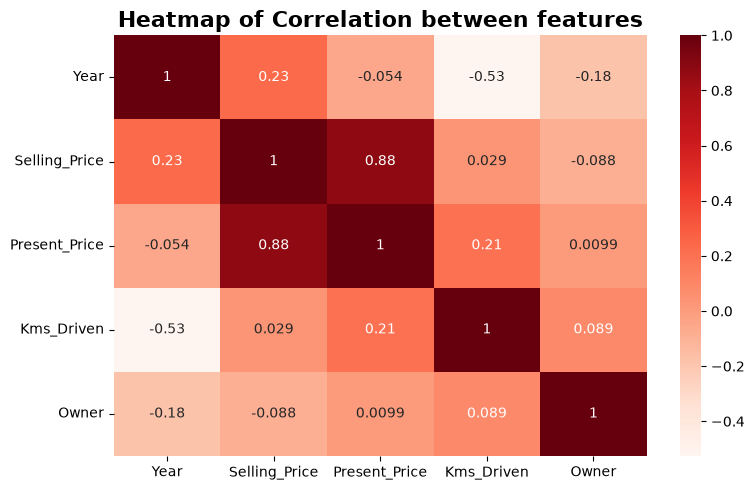

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='Reds')
plt.title('Heatmap of Correlation between features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
for column in df1.columns :
    print(f"\n{column}:")
    print(df1[column].unique())


Car_Name:
<ArrowStringArray>
[                     'ritz',                       'sx4',
                      'ciaz',                   'wagon r',
                     'swift',             'vitara brezza',
                   's cross',                  'alto 800',
                    'ertiga',                     'dzire',
                  'alto k10',                     'ignis',
                       '800',                    'baleno',
                      'omni',                  'fortuner',
                    'innova',             'corolla altis',
               'etios cross',                   'etios g',
                'etios liva',                   'corolla',
                  'etios gd',                     'camry',
              'land cruiser', 'Royal Enfield Thunder 500',
        'UM Renegade Mojave',                 'KTM RC200',
         'Bajaj Dominar 400', 'Royal Enfield Classic 350',
                 'KTM RC390',            'Hyosung GT250R',
 'Royal Enfield Thunder 35

In [25]:
df1.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000


In [26]:
df1["age"] = 2026 - df1["Year"]
df1

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [27]:
df1.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,age
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639,-1.000000
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880,-0.234369
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947,0.053563
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367,0.525714
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000,0.181639
age,-1.000000,-0.234369,0.053563,0.525714,0.181639,1.000000


In [28]:
df1.drop("Year",axis=1 , inplace=True)
df1

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [29]:
Data = df1.copy()

for i in df1.columns :
    Data[i] = Data[i].replace(["Petrol"],2)
    Data[i] = Data[i].replace(["Diesel"],3)
    Data[i] = Data[i].replace(["CNG"],4)
    
    Data[i] = Data[i].replace(["Dealer"],2)
    Data[i] = Data[i].replace(["Individual"],3)
    
    Data[i] = Data[i].replace(["Manual"],2)
    Data[i] = Data[i].replace(["Automatic"],3)


Data = Data.drop(['Car_Name'], axis=1)
Data.sort_values(by="age")
    

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
5,9.25,9.83,2071,3,2,2,0,8
2,7.25,9.85,6900,2,2,2,0,9
27,6.00,6.49,16200,2,3,2,0,9
268,4.80,5.80,19000,2,2,2,0,9
64,33.00,36.23,6000,3,2,3,0,9
...,...,...,...,...,...,...,...,...
84,3.49,13.46,197176,3,2,2,0,21
54,2.75,10.21,90000,2,3,2,0,21
77,1.50,12.35,135154,2,2,3,0,22
37,0.35,2.28,127000,2,3,2,0,23


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 28px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.5px;
  ">
    Modeling with Outliers
  </h2>
  <div style="
    width: 120px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [30]:
x = Data.drop("Selling_Price" , axis = 1)
y = Data["Selling_Price"].values.reshape(-1,1)

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state=0)

regressor = LinearRegression()
regressor.fit(x_train , y_train)

y_pred = regressor.predict(x_test)



print ("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)


print("mean absolute Error :",metrics.mean_absolute_error(y_test, y_pred))
print("mean squard Error :", metrics.mean_squared_error(y_test , y_pred))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test , y_pred)))

print("R2 Score :", metrics.r2_score(y_test , y_pred))

x_train shape : (239, 7)
x_test shape : (60, 7)
y_train shape : (239, 1)
y_test shape : (60, 1)
mean absolute Error : 1.3135565633816213
mean squard Error : 4.422233984694459
RMSE : 2.1029108361255973
R2 Score : 0.7471833417701661


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 26px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.4px;
  ">
    Model Score without Removing Outliers: 74%
  </h2>
  <div style="
    width: 140px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 26px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.4px;
  ">
    Visual Analysis of the Model
  </h2>
  <div style="
    width: 140px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>


Text(0, 0.5, 'y_test')

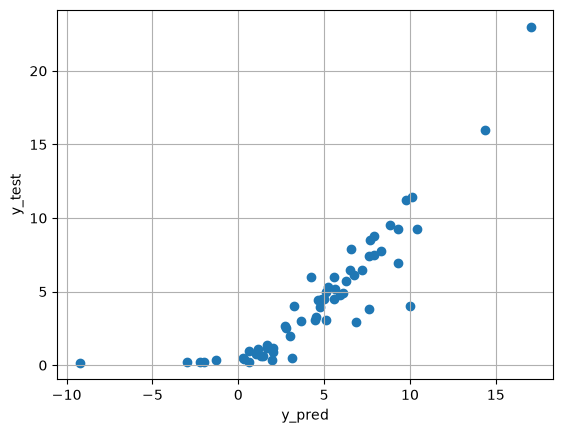

In [31]:
plt.scatter(y_pred , y_test)
plt.grid()
plt.xlabel("y_pred")
plt.ylabel("y_test")

<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Note:</strong> The variation range between y_pred and y_test is large, so the model needs to be improved.
</div>

In [32]:
x


,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,5.59,27000,2,2,2,0,12
1,9.54,43000,3,2,2,0,13
2,9.85,6900,2,2,2,0,9
3,4.15,5200,2,2,2,0,15
4,6.87,42450,3,2,2,0,12
...,...,...,...,...,...,...,...
296,11.60,33988,3,2,2,0,10
297,5.90,60000,2,2,2,0,11
298,11.00,87934,2,2,2,0,17
299,12.50,9000,3,2,2,0,9


In [33]:
y

array([[ 3.35],
       [ 4.75],
       [ 7.25],
       [ 2.85],
       [ 4.6 ],
       [ 9.25],
       [ 6.75],
       [ 6.5 ],
       [ 8.75],
       [ 7.45],
       [ 2.85],
       [ 6.85],
       [ 7.5 ],
       [ 6.1 ],
       [ 2.25],
       [ 7.75],
       [ 7.25],
       [ 3.25],
       [ 2.65],
       [ 2.85],
       [ 4.9 ],
       [ 4.4 ],
       [ 2.5 ],
       [ 2.9 ],
       [ 3.  ],
       [ 4.15],
       [ 6.  ],
       [ 1.95],
       [ 7.45],
       [ 3.1 ],
       [ 2.35],
       [ 4.95],
       [ 6.  ],
       [ 5.5 ],
       [ 2.95],
       [ 4.65],
       [ 0.35],
       [ 3.  ],
       [ 2.25],
       [ 5.85],
       [ 2.55],
       [ 1.95],
       [ 5.5 ],
       [ 1.25],
       [ 7.5 ],
       [ 2.65],
       [ 1.05],
       [ 5.8 ],
       [ 7.75],
       [14.9 ],
       [23.  ],
       [18.  ],
       [16.  ],
       [ 2.75],
       [ 3.6 ],
       [ 4.5 ],
       [ 4.75],
       [ 4.1 ],
       [19.99],
       [ 6.95],
       [ 4.5 ],
       [18.75],
       [

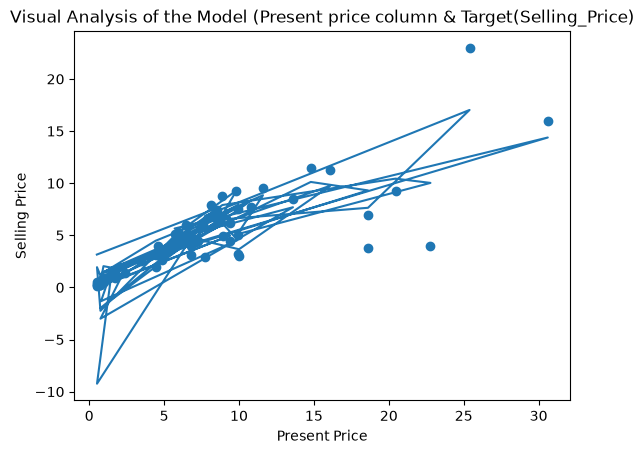

In [34]:
a = x_test.Present_Price
b = y_test
d = y_pred

plt.title("Visual Analysis of the Model (Present price column & Target(Selling_Price)")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.scatter(a , b)
plt.plot(a ,d)

plt.show()

<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Note:</strong> The data needs to be sorted so that the model's behavior can be properly observed in the chart.
</div>

In [35]:
x_test1 = x_test.copy()
x_test1.insert(7 , "y_test",y_test)
x_test1.insert(8 , "y_pred",y_pred)
df2 = x_test1.sort_values(by=["age"])
df2

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age,y_test,y_pred
5,9.830,2071,3,2,2,0,8,9.25,9.297405
208,8.100,3435,2,2,2,0,9,7.90,6.581349
265,8.700,21200,2,2,2,0,9,6.50,6.504329
126,0.950,1300,2,3,2,0,9,0.90,2.040431
155,0.510,4300,2,3,3,0,9,0.48,3.152159
82,25.390,15000,3,2,3,0,9,23.00,17.026511
27,6.490,16200,2,3,2,0,9,6.00,4.217224
15,10.790,43000,3,2,2,0,10,7.75,8.311116
8,8.890,20273,3,2,2,0,10,8.75,7.905718
141,0.800,20000,2,3,2,0,10,0.60,1.301103


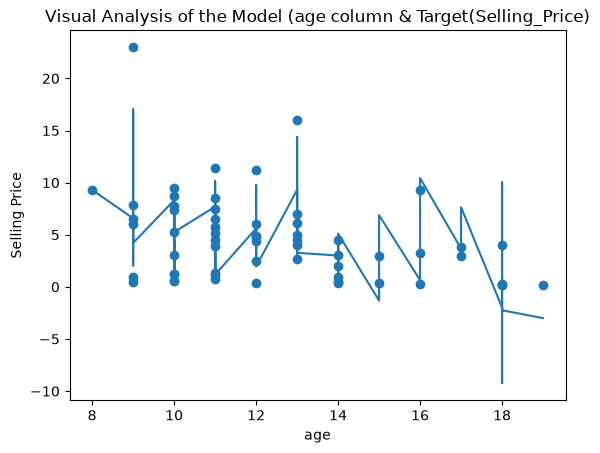

In [36]:
a = df2.age
b = df2.y_test
d = df2.y_pred

plt.title("Visual Analysis of the Model (age column & Target(Selling_Price)")
plt.xlabel("age")
plt.ylabel("Selling Price")

plt.scatter(a , b)
plt.plot(a ,d)

plt.show()

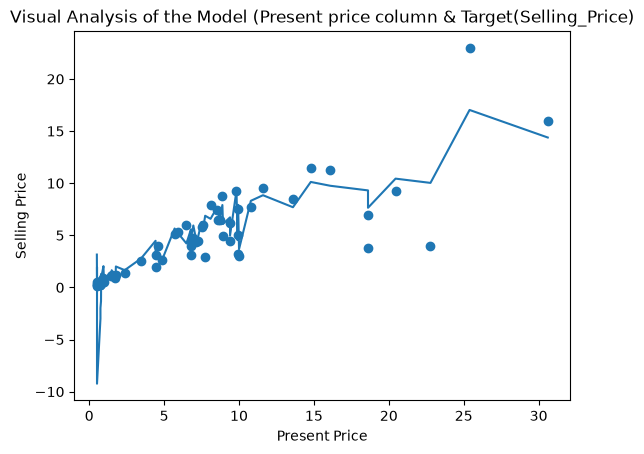

In [37]:
df3 = x_test1.sort_values(by=["Present_Price"])

a = df3.Present_Price
b = df3.y_test
d = df3.y_pred

plt.title("Visual Analysis of the Model (Present price column & Target(Selling_Price)")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.scatter(a , b)
plt.plot(a ,d)

plt.show()

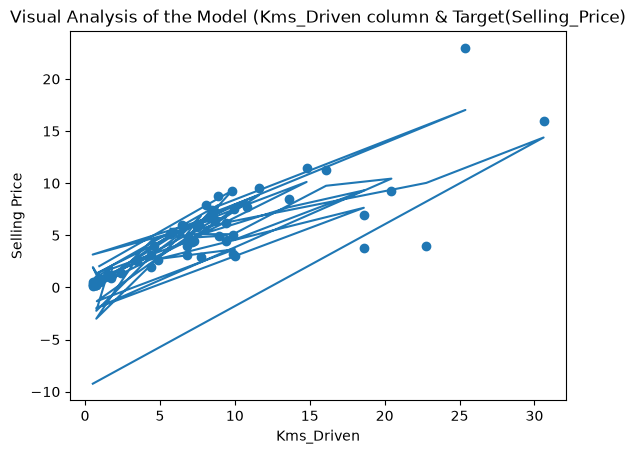

In [38]:
df4 = x_test1.sort_values(by=["Kms_Driven"])

a = df4.Present_Price
b = df4.y_test
d = df4.y_pred

plt.title("Visual Analysis of the Model (Kms_Driven column & Target(Selling_Price)")
plt.xlabel("Kms_Driven")
plt.ylabel("Selling Price")

plt.scatter(a , b)
plt.plot(a ,d)

plt.show()

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Numerical and Precise Comparison of Actual vs Predicted Values
  </h2>
  <div style="
    width: 160px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [39]:
compare = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predict': y_pred.flatten()
})

compare

,Actual,Predict
0,7.90,6.581349
1,0.20,-1.979333
2,7.50,7.920935
3,4.50,5.569061
4,2.00,3.003330
5,0.60,1.429079
6,6.15,6.722486
7,5.15,5.650734
8,16.00,14.383358
9,1.20,2.008322


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Improving the Model by Changing the Test Size
  </h2>
  <div style="
    width: 160px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [40]:
x1 = Data.drop("Selling_Price" , axis = 1)
y1 = Data["Selling_Price"].values.reshape(-1,1)

x_train , x_test , y_train , y_test = train_test_split(x1 , y1 , test_size = 0.3 , random_state=0)

regressor1 = LinearRegression()
regressor1.fit(x_train , y_train)

y_pred = regressor1.predict(x_test)



print ("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)


print("mean absolute Error :",metrics.mean_absolute_error(y_test, y_pred))
print("mean squard Error :", metrics.mean_squared_error(y_test , y_pred))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test , y_pred)))

print("R2 Score :", metrics.r2_score(y_test , y_pred))

x_train shape : (209, 7)
x_test shape : (90, 7)
y_train shape : (209, 1)
y_test shape : (90, 1)
mean absolute Error : 1.2296909289860192
mean squard Error : 4.60068675565072
RMSE : 2.144921153714215
R2 Score : 0.809834397415796


In [41]:
x2 = Data.drop("Selling_Price" , axis = 1)
y2 = Data["Selling_Price"].values.reshape(-1,1)

x_train , x_test , y_train , y_test = train_test_split(x2 , y2 , test_size = 0.25 , random_state=0)

regressor2 = LinearRegression()
regressor2.fit(x_train , y_train)

y_pred = regressor2.predict(x_test)



print ("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)


print("mean absolute Error :",metrics.mean_absolute_error(y_test, y_pred))
print("mean squard Error :", metrics.mean_squared_error(y_test , y_pred))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test , y_pred)))

print("R2 Score :", metrics.r2_score(y_test , y_pred))

x_train shape : (224, 7)
x_test shape : (75, 7)
y_train shape : (224, 1)
y_test shape : (75, 1)
mean absolute Error : 1.290852409890034
mean squard Error : 5.16244188160148
RMSE : 2.272100763963051
R2 Score : 0.8020781279408706


<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Note:</strong> A test size of 30% performs better.
</div>

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Removing Outliers and Re-Modeling
  </h2>
  <div style="
    width: 160px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>


In [42]:
Data

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,3.35,5.59,27000,2,2,2,0,12
1,4.75,9.54,43000,3,2,2,0,13
2,7.25,9.85,6900,2,2,2,0,9
3,2.85,4.15,5200,2,2,2,0,15
4,4.60,6.87,42450,3,2,2,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,2,2,0,10
297,4.00,5.90,60000,2,2,2,0,11
298,3.35,11.00,87934,2,2,2,0,17
299,11.50,12.50,9000,3,2,2,0,9


In [43]:
Data.loc[[85,86,196]]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
85,2.50,23.73,142000,2,3,3,3,20
86,35.00,92.60,78000,3,2,2,0,16
196,0.17,0.52,500000,2,3,3,0,18


In [44]:
Data1 = Data.drop(index=[85,86,196])

In [45]:
x3 = Data1.drop("Selling_Price" , axis = 1)
y3 = Data1["Selling_Price"].values.reshape(-1,1)

x_train , x_test , y_train , y_test = train_test_split(x3 , y3 , test_size = 0.3 , random_state=0)

regressor3 = LinearRegression()
regressor3.fit(x_train , y_train)

y_pred = regressor3.predict(x_test)



print ("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)


print("mean absolute Error :",metrics.mean_absolute_error(y_test, y_pred))
print("mean squard Error :", metrics.mean_squared_error(y_test , y_pred))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test , y_pred)))

print("R2 Score :", metrics.r2_score(y_test , y_pred))

x_train shape : (207, 7)
x_test shape : (89, 7)
y_train shape : (207, 1)
y_test shape : (89, 1)
mean absolute Error : 1.0873658063814897
mean squard Error : 3.5047843953948763
RMSE : 1.8721069401599035
R2 Score : 0.8686645743561467


<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #ecfdf5;
  border-left: 5px solid #10b981;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #065f46;
  line-height: 1.5;
">
  <strong>Result:</strong> The model score increased by 6% → <strong>86%</strong>
</div>

In [48]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipeline = make_pipeline(StandardScaler(), regressor3)

results = cross_validate(
    pipeline, x3, y3,
    cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

print("Train R2:", results['train_r2'])
print("Test R2 :", results['test_r2'])
print("Test RMSE:", -results['test_neg_root_mean_squared_error']) 


Train R2: [0.90183659 0.89409427 0.88030074 0.8799032  0.88186264]
Test R2 : [0.79008431 0.84743994 0.9130555  0.90667692 0.89616418]
Test RMSE: [1.93230931 1.95354698 1.25305396 1.47681541 1.58140382]


<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #ecfdf5;
  border-left: 5px solid #10b981;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #065f46;
  line-height: 1.5;
">
  <strong>Result:</strong> The model was finalized with a score of approximately <strong>87%</strong>.
</div>